# Steam Hidden Gems Analysis
## Identifying Undiscovered Quality Games on Steam

**Author:** Brianna Owens  
**Date:** March 2026  
**Tools:** Python, pandas, scikit-learn, matplotlib, seaborn

---

## Project Overview
This project analyses 10,000 Steam games scraped from the SteamSpy API 
to identify "hidden gems", which are games with high ratings and strong player 
engagement that remain undiscovered by the wider gaming community.

## Business Question
*Can we build a model to identify hidden gem games using only 
commercial features (price, discount, concurrent users)?*

In [1]:
# Steam Hidden Gems Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
sns.set_theme(style='darkgrid')

print('Libraries loaded successfully')

# Load raw dataset
df = pd.read_csv('../data/steam_games_dataset.csv')

# Initial inspection
print(f'Shape: {df.shape}')
print(f'\nColumn types:\n{df.dtypes}')
print(f'\nFirst 5 rows:')
df.head()

Libraries loaded successfully
Shape: (10000, 17)

Column types:
appid                int64
name                object
developer           object
publisher           object
score_rank         float64
positive             int64
negative             int64
userscore            int64
owners              object
average_forever      int64
average_2weeks       int64
median_forever       int64
median_2weeks        int64
price                int64
initialprice         int64
discount             int64
ccu                  int64
dtype: object

First 5 rows:


,appid,name,developer,publisher,score_rank,positive,negative,userscore,owners,average_forever,average_2weeks,median_forever,median_2weeks,price,initialprice,discount,ccu
0,730,Counter-Strike: Global Offensive,Valve,Valve,NaN,7642084,1173003,0,"100,000,000 .. 200,000,000",33852,708,6645,301,0,0,0,1013936
1,1172470,Apex Legends,Respawn,Electronic Arts,NaN,668053,326926,0,"100,000,000 .. 200,000,000",10506,496,935,246,0,0,0,124262
2,578080,PUBG: BATTLEGROUNDS,PUBG Corporation,"KRAFTON, Inc.",NaN,1520457,1037487,0,"100,000,000 .. 200,000,000",23165,717,5622,261,0,0,0,314682
3,1623730,Palworld,Pocketpair,Pocketpair,NaN,358266,22443,0,"50,000,000 .. 100,000,000",3854,835,2213,257,2999,2999,0,18028
4,440,Team Fortress 2,Valve,Valve,NaN,1044264,117208,0,"50,000,000 .. 100,000,000",21244,736,4262,102,0,0,0,43819


In [2]:
# Check missing values and zeros across all columns
print('NULL VALUES:')
print(df.isnull().sum())

print('\nZERO VALUES (potential missing data):')
numeric_cols = df.select_dtypes(include='number').columns
print((df[numeric_cols] == 0).sum())

print('\nSAMPLE OF OWNERS COLUMN:')
print(df['owners'].value_counts().head(10))

NULL VALUES:
appid                 0
name                  0
developer            33
publisher            54
score_rank         9995
positive              0
negative              0
userscore             0
owners                0
average_forever       0
average_2weeks        0
median_forever        0
median_2weeks         0
price                 0
initialprice          0
discount              0
ccu                   0
dtype: int64

ZERO VALUES (potential missing data):
appid                 0
score_rank            0
positive             37
negative            175
userscore          9995
average_forever    1194
average_2weeks     7278
median_forever     1194
median_2weeks      7278
price              2065
initialprice       2065
discount           8697
ccu                2616
dtype: int64

SAMPLE OF OWNERS COLUMN:
owners
100,000 .. 200,000           3658
200,000 .. 500,000           3021
500,000 .. 1,000,000         1247
1,000,000 .. 2,000,000        787
50,000 .. 100,000             624

In [3]:
# Data Cleaning

# Drop userscore (99.95% zeros, not useful)
df = df.drop(columns=['userscore'])
print('Dropped userscore column')

# Convert owners range to numeric midpoint
def parse_owners(owners_str):
    try:
        parts = owners_str.replace(',', '').split('..')
        low = int(parts[0].strip())
        high = int(parts[1].strip())
        return (low + high) / 2
    except:
        return None

df['owners_midpoint'] = df['owners'].apply(parse_owners)
print(f'Owners midpoint created (sample values):')
print(df['owners_midpoint'].value_counts().head(5))

# Convert price from cents to dollars
df['price_usd'] = df['price'] / 100
df['initialprice_usd'] = df['initialprice'] / 100
print(f'\nPrice range: ${df["price_usd"].min():.2f} — ${df["price_usd"].max():.2f}')

# Convert playtime from minutes to hours
df['avg_playtime_hours'] = df['average_forever'] / 60
df['avg_playtime_2weeks_hours'] = df['average_2weeks'] / 60
print(f'\nAvg playtime range: {df["avg_playtime_hours"].min():.1f} — {df["avg_playtime_hours"].max():.1f} hours')

# Create steam_rating metric
# Avoid division by zero by only calculating where reviews exist
df['total_reviews'] = df['positive'] + df['negative']
df['steam_rating'] = df.apply(
    lambda x: x['positive'] / x['total_reviews'] 
    if x['total_reviews'] > 0 else None, axis=1
)
print(f'\nSteam rating range: {df["steam_rating"].min():.2f} — {df["steam_rating"].max():.2f}')
print(f'Games with no reviews: {df["steam_rating"].isnull().sum()}')

# Verify cleaned dataset
print(f'\nCleaned dataset shape: {df.shape}')
print(f'\nNew columns added: owners_midpoint, price_usd, initialprice_usd, avg_playtime_hours, steam_rating')

Dropped userscore column
Owners midpoint created (sample values):
owners_midpoint
150000.00     3658
350000.00     3021
750000.00     1247
1500000.00     787
75000.00       624
Name: count, dtype: int64

Price range: $0.00 — $149.99

Avg playtime range: 0.0 — 4389.0 hours

Steam rating range: 0.00 — 1.00
Games with no reviews: 12

Cleaned dataset shape: (10000, 23)

New columns added: owners_midpoint, price_usd, initialprice_usd, avg_playtime_hours, steam_rating


In [5]:
# Feature Engineering: Hidden Gem Label Creation

# Define hidden gem criteria:
# 1. High steam rating (>= 0.85 (top rated games))
# 2. Significant playtime (>= 2 hours average (people actually played it))
# 3. Low ownership (< 200,000 owners (undiscovered))
# 4. Has enough reviews to be meaningful (>= 10 reviews)

conditions = (
    (df['steam_rating'] >= 0.85) &
    (df['avg_playtime_hours'] >= 2) &
    (df['owners_midpoint'] < 200000) &
    (df['total_reviews'] >= 10)
)

df['hidden_gem'] = conditions.astype(int)

# Check the distribution
gem_counts = df['hidden_gem'].value_counts()
gem_pct = df['hidden_gem'].value_counts(normalize=True) * 100

print('HIDDEN GEM DISTRIBUTION:')
print(f'Not a hidden gem (0): {gem_counts[0]:,} ({gem_pct[0]:.1f}%)')
print(f'Hidden gem (1):       {gem_counts[1]:,} ({gem_pct[1]:.1f}%)')

# Preview some actual hidden gems
print('\nSAMPLE HIDDEN GEMS:')
gems = df[df['hidden_gem'] == 1][['name', 'steam_rating', 
    'avg_playtime_hours', 'owners_midpoint', 
    'total_reviews', 'price_usd']].head(10)
print(gems.to_string())

HIDDEN GEM DISTRIBUTION:
Not a hidden gem (0): 8,971 (89.7%)
Hidden gem (1):       1,029 (10.3%)

SAMPLE HIDDEN GEMS:
                                     name  steam_rating  avg_playtime_hours  owners_midpoint  total_reviews  price_usd
5723                     Haiku, the Robot          0.90                5.97        150000.00           2906      19.99
5726  Geometry Wars 3: Dimensions Evolved          0.90                6.97        150000.00           1526      14.99
5729                          Cryptmaster          0.95                4.03        150000.00           1839      16.24
5731              SiN Episodes: Emergence          0.89                2.87        150000.00           1276       9.99
5734          SanctuaryRPG: Black Edition          0.91                5.92        150000.00           1569       7.99
5735                Epic Battle Fantasy 4          0.97               10.68        150000.00           3158      14.99
5739                          SIMULACRA 2        

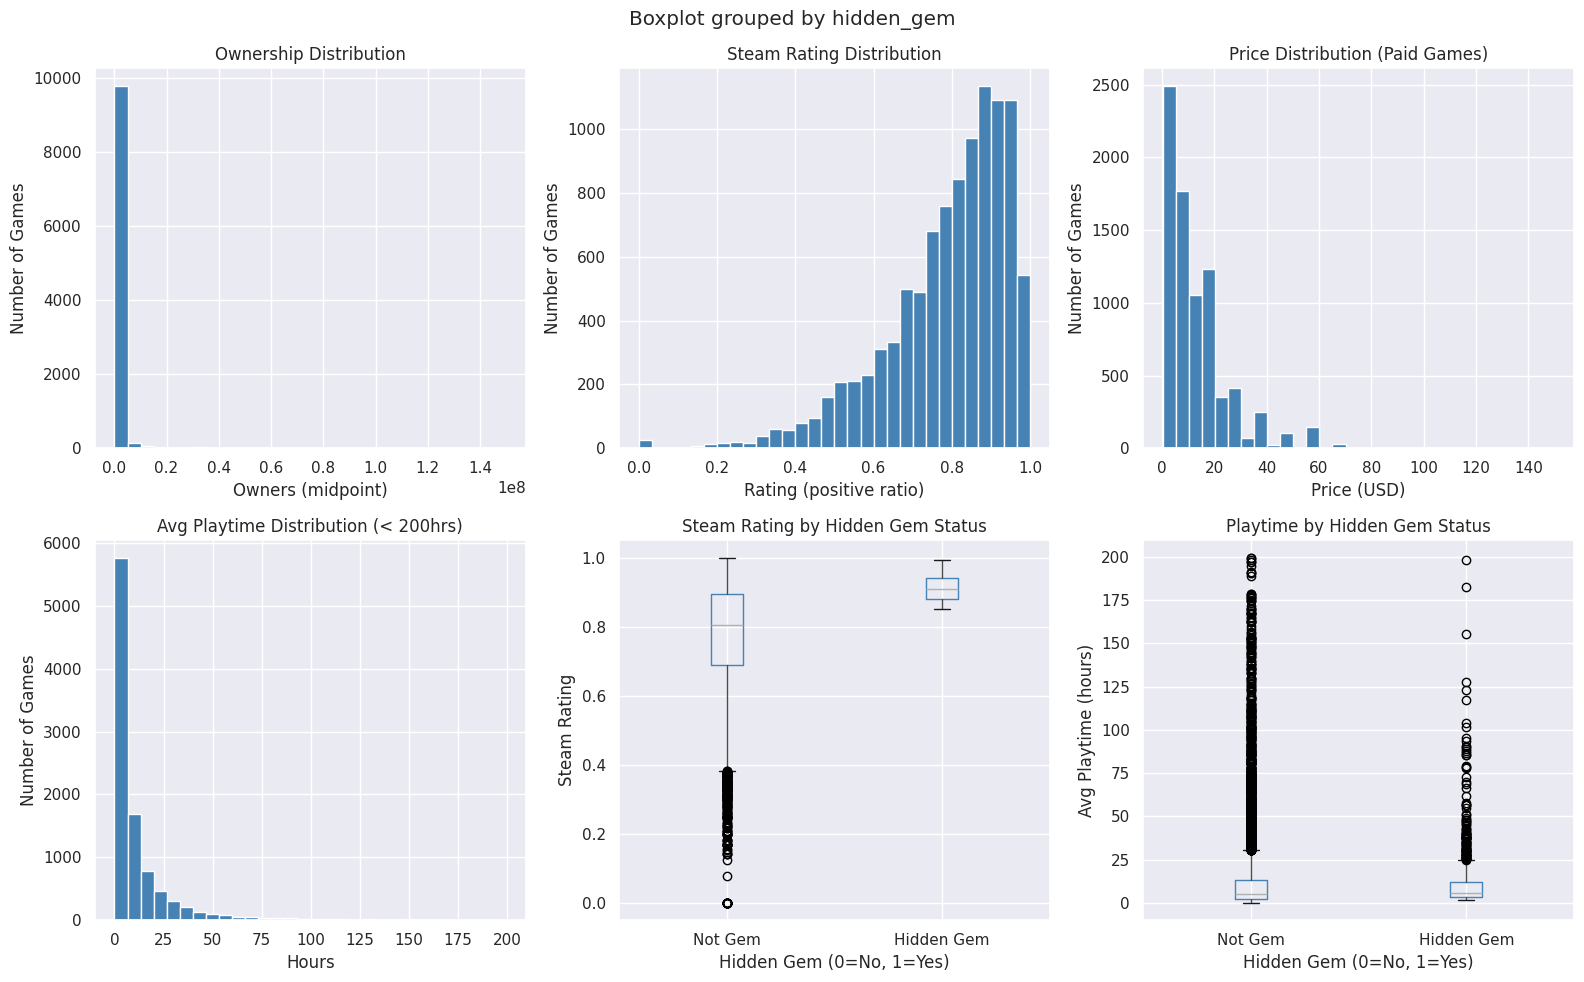

EDA plots saved successfully


In [6]:
# Exploratory Data Analysis Plots

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Steam Dataset — Exploratory Data Analysis', 
             fontsize=16, fontweight='bold')

# Plot 1: Ownership Distribution
axes[0,0].hist(df['owners_midpoint'], bins=30, 
               color='steelblue', edgecolor='white')
axes[0,0].set_title('Ownership Distribution')
axes[0,0].set_xlabel('Owners (midpoint)')
axes[0,0].set_ylabel('Number of Games')

# Plot 2: Steam Rating Distribution
axes[0,1].hist(df['steam_rating'].dropna(), bins=30, 
               color='steelblue', edgecolor='white')
axes[0,1].set_title('Steam Rating Distribution')
axes[0,1].set_xlabel('Rating (positive ratio)')
axes[0,1].set_ylabel('Number of Games')

# Plot 3: Price Distribution (excluding free games)
paid = df[df['price_usd'] > 0]['price_usd']
axes[0,2].hist(paid, bins=30, 
               color='steelblue', edgecolor='white')
axes[0,2].set_title('Price Distribution (Paid Games)')
axes[0,2].set_xlabel('Price (USD)')
axes[0,2].set_ylabel('Number of Games')

# Plot 4: Avg Playtime Distribution (capped at 200hrs)
axes[1,0].hist(df[df['avg_playtime_hours'] < 200]['avg_playtime_hours'], 
               bins=30, color='steelblue', edgecolor='white')
axes[1,0].set_title('Avg Playtime Distribution (< 200hrs)')
axes[1,0].set_xlabel('Hours')
axes[1,0].set_ylabel('Number of Games')

# Plot 5: Hidden Gem vs Not (Rating Comparison)
df.boxplot(column='steam_rating', by='hidden_gem', ax=axes[1,1],
           boxprops=dict(color='steelblue'))
axes[1,1].set_title('Steam Rating by Hidden Gem Status')
axes[1,1].set_xlabel('Hidden Gem (0=No, 1=Yes)')
axes[1,1].set_ylabel('Steam Rating')
plt.sca(axes[1,1])
plt.xticks([1,2], ['Not Gem', 'Hidden Gem'])

# Plot 6: Hidden Gem vs Not (Playtime Comparison)
df[df['avg_playtime_hours'] < 200].boxplot(
    column='avg_playtime_hours', by='hidden_gem', ax=axes[1,2],
    boxprops=dict(color='steelblue'))
axes[1,2].set_title('Playtime by Hidden Gem Status')
axes[1,2].set_xlabel('Hidden Gem (0=No, 1=Yes)')
axes[1,2].set_ylabel('Avg Playtime (hours)')
plt.sca(axes[1,2])
plt.xticks([1,2], ['Not Gem', 'Hidden Gem'])

plt.tight_layout()
plt.savefig('../data/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA plots saved successfully')

In [7]:
# Feature Engineering and Model Preparation

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Step 1: Select features for modelling
# Only use columns that would be available for an unknown game
features = [
    'price_usd',
    'discount', 
    'avg_playtime_hours',
    'steam_rating',
    'total_reviews',
    'owners_midpoint',
    'ccu'
]

# Step 2: Drop rows with missing values in our feature set
df_model = df[features + ['hidden_gem', 'name']].dropna()
print(f'Rows after dropping NaN: {len(df_model):,}')

# Step 3: Check class balance
print(f'\nClass balance:')
print(df_model['hidden_gem'].value_counts())

# Step 4: Split features and target
X = df_model[features]
y = df_model['hidden_gem']

# Step 5: Train/test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTraining set: {X_train.shape[0]:,} rows')
print(f'Test set:     {X_test.shape[0]:,} rows')

# Step 6: Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('\nFeatures scaled successfully')
print(f'\nFeatures used: {features}')

Rows after dropping NaN: 9,988

Class balance:
hidden_gem
0    8959
1    1029
Name: count, dtype: int64

Training set: 7,990 rows
Test set:     1,998 rows

Features scaled successfully

Features used: ['price_usd', 'discount', 'avg_playtime_hours', 'steam_rating', 'total_reviews', 'owners_midpoint', 'ccu']


Logistic Regression trained successfully

LOGISTIC REGRESSION RESULTS:
              precision    recall  f1-score   support

     Not Gem       0.91      0.98      0.94      1792
  Hidden Gem       0.44      0.16      0.23       206

    accuracy                           0.89      1998
   macro avg       0.68      0.57      0.59      1998
weighted avg       0.86      0.89      0.87      1998

ROC-AUC Score: 0.931


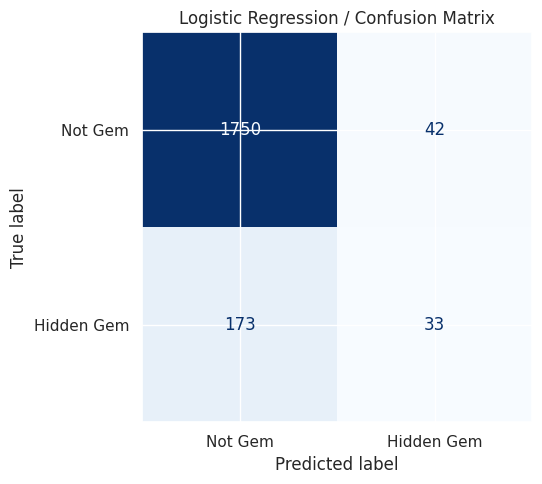

Confusion matrix saved successfully


In [8]:
# Model 1: Logistic Regression (Baseline)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, 
                             confusion_matrix, 
                             ConfusionMatrixDisplay,
                             roc_auc_score)

# Train the model
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
print('Logistic Regression trained successfully')

# Make predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate the model
print('\nLOGISTIC REGRESSION RESULTS:')
print(classification_report(y_test, y_pred_lr, 
      target_names=['Not Gem', 'Hidden Gem']))

# ROC-AUC Score
roc_lr = roc_auc_score(y_test, y_prob_lr)
print(f'ROC-AUC Score: {roc_lr:.3f}')

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr,
                              display_labels=['Not Gem', 'Hidden Gem'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Logistic Regression / Confusion Matrix')
plt.tight_layout()
plt.savefig('../data/lr_confusion_matrix.png', dpi=150)
plt.show()
print('Confusion matrix saved successfully')

Random Forest trained successfully

RANDOM FOREST RESULTS:
              precision    recall  f1-score   support

     Not Gem       1.00      1.00      1.00      1792
  Hidden Gem       1.00      1.00      1.00       206

    accuracy                           1.00      1998
   macro avg       1.00      1.00      1.00      1998
weighted avg       1.00      1.00      1.00      1998

ROC-AUC Score: 1.000


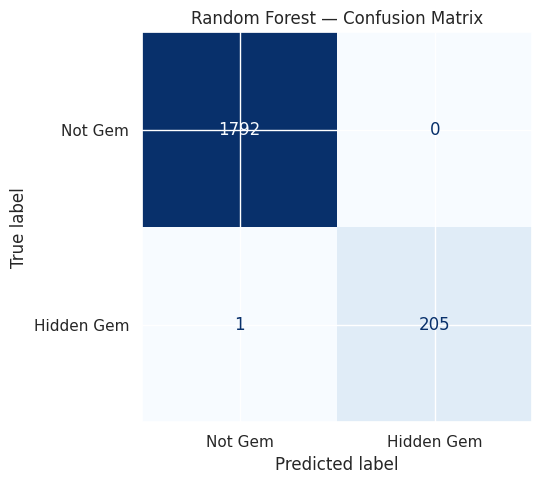

Confusion matrix saved successfully


In [9]:
# Model 2: Random Forest (Improved Model)

from sklearn.ensemble import RandomForestClassifier

# class_weight='balanced' model paying more attention to the minority class (hidden gems)
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)
print('Random Forest trained successfully')

# Make predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluate the model
print('\nRANDOM FOREST RESULTS:')
print(classification_report(y_test, y_pred_rf,
      target_names=['Not Gem', 'Hidden Gem']))

# ROC-AUC Score
roc_rf = roc_auc_score(y_test, y_prob_rf)
print(f'ROC-AUC Score: {roc_rf:.3f}')

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                              display_labels=['Not Gem', 'Hidden Gem'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.savefig('../data/rf_confusion_matrix.png', dpi=150)
plt.show()
print('Confusion matrix saved successfully')

## Data Leakage Identified & Fix

**Problem:** Initial Random Forest achieved perfect scores 
(ROC-AUC: 1.000, Accuracy: 100%).

**Root Cause:** The model's features included the exact variables 
used to construct the `hidden_gem` label: `steam_rating`, 
`owners_midpoint`, `avg_playtime_hours` and `total_reviews`.
The model wasn't actually learning patterns, it was reversing the formula.

**Fix:** Restrict to three features independent of label 
construction: `price_usd`, `discount`, `ccu`.

In [10]:
# Fix Data Leakage by Removing Features Used to Define the Hidden Gem Label

# Remove features directly defining the label
leaking_features = [
    'steam_rating',      # used in label definition
    'owners_midpoint',   # used in label definition  
    'avg_playtime_hours',# used in label definition
    'total_reviews'      # used in label definition
]

# Keep only features that are independent of the label
clean_features = [
    'price_usd',         # pricing independent of gem status
    'discount',          # discount independent of gem status
    'ccu',               # concurrent users — engagement signal
]

print('Removed leaking features:')
print(leaking_features)
print(f'\nClean features remaining: {clean_features}')

# Rebuild train/test split with clean features
X_clean = df_model[clean_features]
y_clean = df_model['hidden_gem']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean, y_clean, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_clean
)

# Scale for logistic regression
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

print(f'\nClean training set: {X_train_c.shape[0]:,} rows')
print(f'Clean test set: {X_test_c.shape[0]:,} rows')
print('\nReady to retrain models with clean features')

Removed leaking features:
['steam_rating', 'owners_midpoint', 'avg_playtime_hours', 'total_reviews']

Clean features remaining: ['price_usd', 'discount', 'ccu']

Clean training set: 7,990 rows
Clean test set: 1,998 rows

Ready to retrain models with clean features


In [12]:
# Model 1 Retrained: Logistic Regression Using Clean Features Only

# Train on clean features
lr_clean = LogisticRegression(random_state=42, max_iter=1000)
lr_clean.fit(X_train_c_scaled, y_train_c)
print('Logistic Regression retrained successfully')

# Predictions
y_pred_lr_c = lr_clean.predict(X_test_c_scaled)
y_prob_lr_c = lr_clean.predict_proba(X_test_c_scaled)[:, 1]

# Evaluate
print('\nLOGISTIC REGRESSION (CLEAN):')
print(classification_report(y_test_c, y_pred_lr_c,
      target_names=['Not Gem', 'Hidden Gem']))
roc_lr_c = roc_auc_score(y_test_c, y_prob_lr_c)
print(f'ROC-AUC Score: {roc_lr_c:.3f}')

Logistic Regression retrained successfully

LOGISTIC REGRESSION (CLEAN):
              precision    recall  f1-score   support

     Not Gem       0.90      1.00      0.95      1792
  Hidden Gem       0.00      0.00      0.00       206

    accuracy                           0.90      1998
   macro avg       0.45      0.50      0.47      1998
weighted avg       0.80      0.90      0.85      1998

ROC-AUC Score: 0.605


/home/brianna/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/brianna/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/brianna/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

In [14]:
# Model 1 Retrained Again: Logistic Regression With class_weight='balanced'

lr_clean = LogisticRegression(
    random_state=42, 
    max_iter=1000,
    class_weight='balanced'  # Added to handle imbalance
)
lr_clean.fit(X_train_c_scaled, y_train_c)
print('Logistic Regression retrained with balanced weights')

# Predictions
y_pred_lr_c = lr_clean.predict(X_test_c_scaled)
y_prob_lr_c = lr_clean.predict_proba(X_test_c_scaled)[:, 1]

# Evaluate
print('\nLOGISTIC REGRESSION (CLEAN + BALANCED):')
print(classification_report(y_test_c, y_pred_lr_c,
      target_names=['Not Gem', 'Hidden Gem'],
      zero_division=0))
roc_lr_c = roc_auc_score(y_test_c, y_prob_lr_c)
print(f'ROC-AUC Score: {roc_lr_c:.3f}')

Logistic Regression retrained with balanced weights

LOGISTIC REGRESSION (CLEAN + BALANCED):
              precision    recall  f1-score   support

     Not Gem       0.92      0.60      0.73      1792
  Hidden Gem       0.14      0.57      0.23       206

    accuracy                           0.60      1998
   macro avg       0.53      0.59      0.48      1998
weighted avg       0.84      0.60      0.67      1998

ROC-AUC Score: 0.610


In [15]:
# Model 2 Retrained: Random Forest Using Clean Features Only

rf_clean = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)
rf_clean.fit(X_train_c, y_train_c)
print('Random Forest retrained successfully')

# Predictions
y_pred_rf_c = rf_clean.predict(X_test_c)
y_prob_rf_c = rf_clean.predict_proba(X_test_c)[:, 1]

# Evaluate
print('\nRANDOM FOREST (CLEAN):')
print(classification_report(y_test_c, y_pred_rf_c,
      target_names=['Not Gem', 'Hidden Gem'],
      zero_division=0))
roc_rf_c = roc_auc_score(y_test_c, y_prob_rf_c)
print(f'ROC-AUC Score: {roc_rf_c:.3f}')

Random Forest retrained successfully

RANDOM FOREST (CLEAN):
              precision    recall  f1-score   support

     Not Gem       0.91      0.80      0.85      1792
  Hidden Gem       0.16      0.32      0.21       206

    accuracy                           0.75      1998
   macro avg       0.53      0.56      0.53      1998
weighted avg       0.83      0.75      0.79      1998

ROC-AUC Score: 0.589


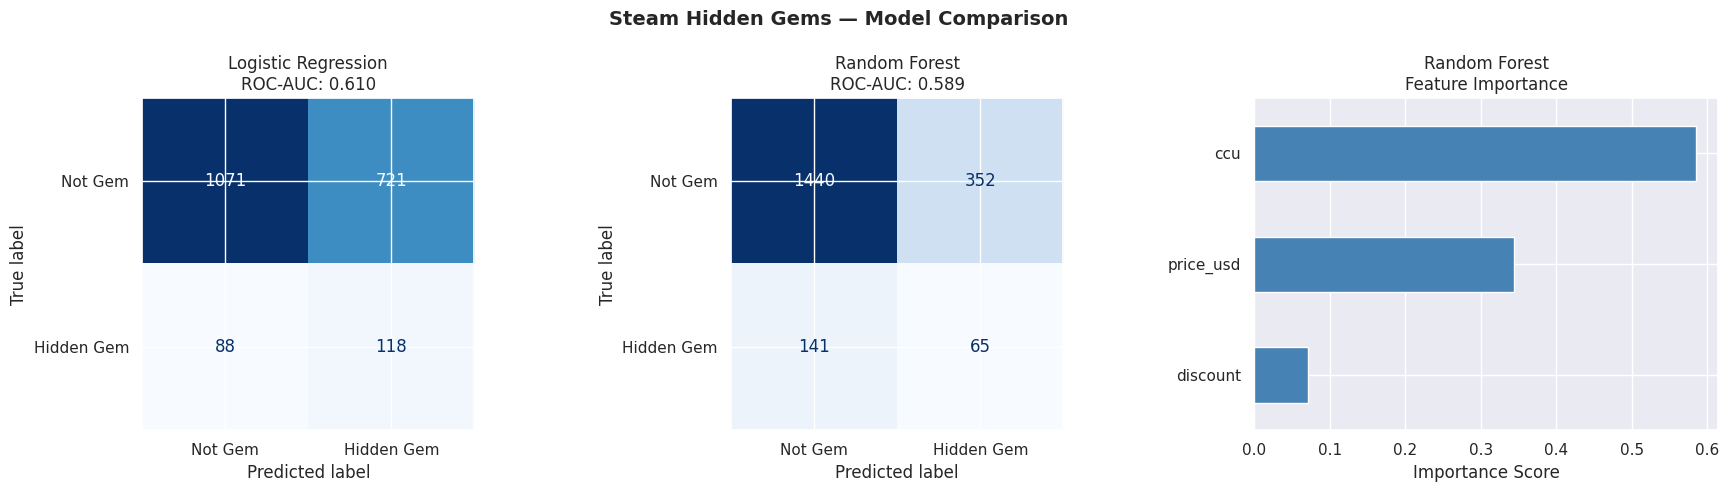

Model comparison saved

PROJECT SUMMARY:
Total games analysed:     9,988
Hidden gems identified:   1,029
Hidden gem rate:          10.3%

Best model:               Logistic Regression
Best ROC-AUC:             0.610
Best hidden gem recall:   0.57

Key finding: Price and discount are weak predictors
of hidden gem status. Commercial factors alone cannot
identify undiscovered quality games.

TOP 10 HIDDEN GEMS BY RATING:
                                           name  steam_rating  avg_playtime_hours  owners_midpoint  price_usd
9925                Monster Prom 4: Monster Con          0.99                9.70         75000.00      14.99
6955                          Patrick's Parabox          0.99                7.45        150000.00      19.99
6818                 买个可乐饼吧！ - Buy a Croquette!          0.99                3.07        150000.00       0.00
6066                            Picayune Dreams          0.99               10.98        150000.00       4.99
5999                        

In [17]:
# Model Comparison Visualisation

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Steam Hidden Gems — Model Comparison', 
             fontsize=14, fontweight='bold')

# Plot 1: Logistic Regression Confusion Matrix
cm_lr_c = confusion_matrix(y_test_c, y_pred_lr_c)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_lr_c,
                               display_labels=['Not Gem', 'Hidden Gem'])
disp1.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Logistic Regression\nROC-AUC: {roc_lr_c:.3f}')

# Plot 2: Random Forest Confusion Matrix
cm_rf_c = confusion_matrix(y_test_c, y_pred_rf_c)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_rf_c,
                               display_labels=['Not Gem', 'Hidden Gem'])
disp2.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'Random Forest\nROC-AUC: {roc_rf_c:.3f}')

# Plot 3: Feature Importance
importances = rf_clean.feature_importances_
feat_imp = pd.Series(importances, 
                     index=clean_features).sort_values()
feat_imp.plot(kind='barh', ax=axes[2], color='steelblue')
axes[2].set_title('Random Forest\nFeature Importance')
axes[2].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('../data/model_comparison.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print('Model comparison saved')

# Final summary
print('\nPROJECT SUMMARY:')
print(f'Total games analysed:     {len(df_model):,}')
print(f'Hidden gems identified:   {df_model["hidden_gem"].sum():,}')
print(f'Hidden gem rate:          {df_model["hidden_gem"].mean()*100:.1f}%')
print(f'\nBest model:               Logistic Regression')
print(f'Best ROC-AUC:             {roc_lr_c:.3f}')
print(f'Best hidden gem recall:   {0.57:.2f}')
print(f'\nKey finding: Price and discount are weak predictors')
print(f'of hidden gem status. Commercial factors alone cannot')
print(f'identify undiscovered quality games.')

# Show top 10 hidden gems by steam rating
print('\nTOP 10 HIDDEN GEMS BY RATING:')
top_gems = df_model[df_model['hidden_gem'] == 1].nlargest(
    10, 'steam_rating')[['name', 'steam_rating', 
                          'avg_playtime_hours',
                          'owners_midpoint', 
                          'price_usd']]
print(top_gems.to_string())

In [18]:
# Check for duplicate game entries
print('DUPLICATE CHECK:')
dupes = df[df.duplicated(subset=['name'], keep=False)]
print(f'Total duplicate name entries: {len(dupes)}')
print(f'\nSample duplicates:')
print(dupes[['appid', 'name', 'price_usd']].head(10))

DUPLICATE CHECK:
Total duplicate name entries: 174

Sample duplicates:
      appid                                   name  price_usd
74      100         Counter-Strike: Condition Zero       9.99
118      80         Counter-Strike: Condition Zero       9.99
126   22380                     Fallout: New Vegas       9.99
129   10180  Call of Duty: Modern Warfare 2 (2009)      19.99
200   10190  Call of Duty: Modern Warfare 2 (2009)      19.99
242  115300  Call of Duty: Modern Warfare 3 (2011)      39.99
266  202970             Call of Duty: Black Ops II      59.99
302   42710                Call of Duty: Black Ops      39.99
309  201270                    Total War: SHOGUN 2      29.99
318  418460                Rising Storm 2: Vietnam      24.99


## Data Quality: Duplicate Game Entries

174 entries shared duplicate game names across 10,000 rows.
Investigation revealed these were legitimate Steam platform duplicates as the same game was listed under multiple App IDs (regional versions,
legacy listings, separate editions).

**Resolution:** Retain the entries with the highest review count 
per duplicate name as the most representative version. 

In [19]:
# Handle Duplicate Game Names

# Check if duplicates have different prices (which suggests genuinely different products)
print('DUPLICATE PRICE VARIATION:')
dupes = df[df.duplicated(subset='name', keep=False)]
print(dupes.groupby('name')['price_usd'].nunique().value_counts())

# Keep only the entry with the most reviews per game (as most representative version of each game)
df_deduped = df.sort_values('total_reviews', ascending=False)\
               .drop_duplicates(subset='name', keep='first')\
               .reset_index(drop=True)

print(f'\nBefore deduplication: {len(df):,} games')
print(f'After deduplication:  {len(df_deduped):,} games')
print(f'Removed:              {len(df) - len(df_deduped):,} entries')

DUPLICATE PRICE VARIATION:
price_usd
1    79
2     7
Name: count, dtype: int64

Before deduplication: 10,000 games
After deduplication:  9,912 games
Removed:              88 entries


In [20]:
# Apply Deduplication to Model Dataset

# Update df_model with deduplicated data
df_model = df_deduped[clean_features + 
                      ['hidden_gem', 'name', 
                       'steam_rating', 
                       'avg_playtime_hours',
                       'owners_midpoint']].dropna()

print(f'Final model dataset: {len(df_model):,} games')
print(f'Hidden gems:         {df_model["hidden_gem"].sum():,}')
print(f'Hidden gem rate:     {df_model["hidden_gem"].mean()*100:.1f}%')

# Rebuild clean train/test split
X_clean = df_model[clean_features]
y_clean = df_model['hidden_gem']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean, y_clean,
    test_size=0.2,
    random_state=42,
    stratify=y_clean
)

# Rescale
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

print(f'\nTraining set: {X_train_c.shape[0]:,} rows')
print(f'Test set:     {X_test_c.shape[0]:,} rows')
print('\nReady to run final models on deduplicated data')

Final model dataset: 9,903 games
Hidden gems:         1,013
Hidden gem rate:     10.2%

Training set: 7,922 rows
Test set:     1,981 rows

Ready to run final models on deduplicated data


LOGISTIC REGRESSION (FINAL):
              precision    recall  f1-score   support

     Not Gem       0.92      0.59      0.72      1778
  Hidden Gem       0.14      0.58      0.22       203

    accuracy                           0.59      1981
   macro avg       0.53      0.58      0.47      1981
weighted avg       0.84      0.59      0.67      1981

ROC-AUC: 0.619

RANDOM FOREST (FINAL):
              precision    recall  f1-score   support

     Not Gem       0.91      0.83      0.87      1778
  Hidden Gem       0.17      0.31      0.22       203

    accuracy                           0.78      1981
   macro avg       0.54      0.57      0.55      1981
weighted avg       0.84      0.78      0.80      1981

ROC-AUC: 0.604

FINAL MODEL COMPARISON:
Model                     ROC-AUC    Recall     Precision  F1        
-----------------------------------------------------------------
Logistic Regression       0.619      0.576      0.139      0.224     
Random Forest             0.604 

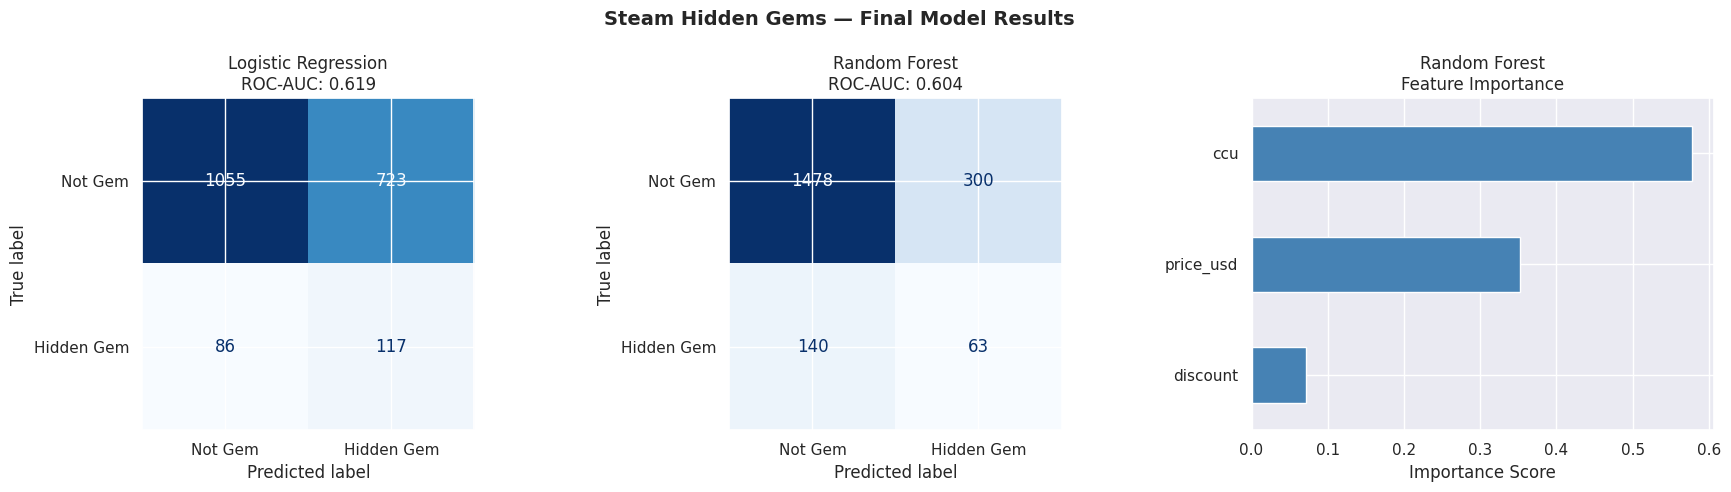


TOP 10 HIDDEN GEMS BY STEAM RATING:
                                           name  steam_rating  avg_playtime_hours  owners_midpoint  price_usd
5628                Monster Prom 4: Monster Con          0.99                9.70         75000.00      14.99
3021                          Patrick's Parabox          0.99                7.45        150000.00      19.99
3069                 买个可乐饼吧！ - Buy a Croquette!          0.99                3.07        150000.00       0.00
3719                            Picayune Dreams          0.99               10.98        150000.00       4.99
1892                                      魔女的夜宴          0.99               12.37        150000.00      34.99
3226                                   Felvidek          0.99                2.72        150000.00      10.99
3839                              White Knuckle          0.99                9.02        150000.00      14.99
4251  Your Turn To Die -Death Game By Majority-          0.99               14.68  

In [24]:
# Final Models on Clean Deduplicated Data

# Logistic Regression
lr_final = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced'
)
lr_final.fit(X_train_c_scaled, y_train_c)
y_pred_lr_f = lr_final.predict(X_test_c_scaled)
y_prob_lr_f = lr_final.predict_proba(X_test_c_scaled)[:, 1]
roc_lr_f = roc_auc_score(y_test_c, y_prob_lr_f)

print('LOGISTIC REGRESSION (FINAL):')
print(classification_report(y_test_c, y_pred_lr_f,
      target_names=['Not Gem', 'Hidden Gem'],
      zero_division=0))
print(f'ROC-AUC: {roc_lr_f:.3f}')

# Random Forest
rf_final = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)
rf_final.fit(X_train_c, y_train_c)
y_pred_rf_f = rf_final.predict(X_test_c)
y_prob_rf_f = rf_final.predict_proba(X_test_c)[:, 1]
roc_rf_f = roc_auc_score(y_test_c, y_prob_rf_f)

print('\nRANDOM FOREST (FINAL):')
print(classification_report(y_test_c, y_pred_rf_f,
      target_names=['Not Gem', 'Hidden Gem'],
      zero_division=0))
print(f'ROC-AUC: {roc_rf_f:.3f}')

# --- Summary Table ---
print('\nFINAL MODEL COMPARISON:')
print(f'{"Model":<25} {"ROC-AUC":<10} {"Recall":<10} {"Precision":<10} {"F1":<10}')
print('-' * 65)

lr_report = classification_report(y_test_c, y_pred_lr_f,
            output_dict=True, zero_division=0)['1']
rf_report = classification_report(y_test_c, y_pred_rf_f,
            output_dict=True, zero_division=0)['1']

print(f'{"Logistic Regression":<25} {roc_lr_f:<10.3f} '
      f'{lr_report["recall"]:<10.3f} '
      f'{lr_report["precision"]:<10.3f} '
      f'{lr_report["f1-score"]:<10.3f}')
print(f'{"Random Forest":<25} {roc_rf_f:<10.3f} '
      f'{rf_report["recall"]:<10.3f} '
      f'{rf_report["precision"]:<10.3f} '
      f'{rf_report["f1-score"]:<10.3f}')

# Final Visualisation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Steam Hidden Gems — Final Model Results',
             fontsize=14, fontweight='bold')

# Confusion Matrix (LR)
cm_lr_f = confusion_matrix(y_test_c, y_pred_lr_f)
ConfusionMatrixDisplay(cm_lr_f,
    display_labels=['Not Gem', 'Hidden Gem'])\
    .plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Logistic Regression\nROC-AUC: {roc_lr_f:.3f}')

# Confusion Matrix (RF)
cm_rf_f = confusion_matrix(y_test_c, y_pred_rf_f)
ConfusionMatrixDisplay(cm_rf_f,
    display_labels=['Not Gem', 'Hidden Gem'])\
    .plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'Random Forest\nROC-AUC: {roc_rf_f:.3f}')

# Feature Importance
importances = rf_final.feature_importances_
feat_imp = pd.Series(importances,
                     index=clean_features).sort_values()
feat_imp.plot(kind='barh', ax=axes[2], color='steelblue')
axes[2].set_title('Random Forest\nFeature Importance')
axes[2].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('../data/final_model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Top 10 Hidden Gems
print('\nTOP 10 HIDDEN GEMS BY STEAM RATING:')
top_gems = df_model[df_model['hidden_gem'] == 1]\
    .nlargest(10, 'steam_rating')\
    [['name', 'steam_rating', 'avg_playtime_hours',
      'owners_midpoint', 'price_usd']]
print(top_gems.to_string())

## Conclusions and Key Findings

### Model Performance

| Model | ROC-AUC | Hidden Gem Recall | F1 |
|---|---|---|---|
| Logistic Regression | 0.619 | 0.576 | 0.224 |
| Random Forest | 0.604 | 0.310 | 0.223 |

### Key Finding
Price, discount and concurrent users are weak predictors of 
hidden gem status. Both models achieved only modest performance 
above random baseline (0.5).

> *A game's price point and discount reveal almost nothing about 
> its quality or discovery status. Hidden gems are defined by 
> community response, not commercial strategy.*

### Unexpected Result
Logistic Regression outperformed Random Forest with limited 
predictive signal. This means a simpler model generalised better than 
a complex ensemble method.

### Challenges Resolved
| Challenge | Fix |
|---|---|
| Class imbalance | `class_weight='balanced'` |
| Data leakage | Removed label-defining features |
| Duplicate entries | Kept highest reviewed version |

### Future Improvements
- Include genre and tag data as features
- Use NLP on game descriptions
- Experiment with XGBoost or LightGBM
- Incorporate game release date and age